In [11]:
import pandas as pd
import numpy as np

# -----------------------------
# Load CSV
# -----------------------------
df = pd.read_csv("three_noisy_signals.csv")

# -----------------------------
# Rebuild global temperature
# -----------------------------
t = df["time"].values

df["global_temperature"] = np.sin(2 * np.pi * 0.5 * t)

# -----------------------------
X_raw = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values

# mask: 1 = observed, 0 = missing
mask = (~np.isnan(X_raw)).astype(float)

# fill missing values with column means
col_means = np.nanmean(X_raw, axis=0)
X_filled = np.where(np.isnan(X_raw), col_means, X_raw)

# add mask channels
X_model = np.concatenate([X_filled, mask], axis=1)

# target
y_raw = df["global_temperature"].values

# reshape
X = X_model[np.newaxis, :, :]          # (1, 200, 6)
y = y_raw[np.newaxis, :, np.newaxis]   # (1, 200, 1)

# normalize
X_mean = X.mean()
X_std = X.std()

y_mean = y.mean()
y_std = y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

print(np.isnan(X_norm).sum())
print(np.isnan(y_norm).sum())
print(X_norm.shape, y_norm.shape)

0
0
(1, 200, 6) (1, 200, 1)


In [12]:
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model

# input shape: (time_steps, features)
inputs = Input(shape=(X_norm.shape[1], X_norm.shape[2]))

# project 3 sensor features into d_model dimensions
x = Dense(64)(inputs)

# self-attention block
attn_output = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(x, x)

attn_output = Dropout(0.1)(attn_output)

# residual connection + normalization
x = LayerNormalization()(x + attn_output)

# feed-forward block
ffn = Dense(128, activation="relu")(x)
ffn = Dense(64)(ffn)
ffn = Dropout(0.1)(ffn)

# residual connection + normalization
x = LayerNormalization()(x + ffn)

# output one global temperature per time point
outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer="adam",
    loss="mse"
)

transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 200, 64)   │        448 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 64)   │     16,640 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 200, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 200, 64)   │          0 │ dense_8[0][0],    │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 200, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 200, 64)   │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 200, 64)   │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 200, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 200, 1)    │         65 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,985 (132.75 KB)

 Trainable params: 33,985 (132.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = transformer_model.fit(
    X_norm,
    y_norm,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 3.3272
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 2.2804
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.6786
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.3373
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.9448
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9510
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.0360
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0314
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.0740
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.1819
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.0645
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.9679
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.8908
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8321
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7472
Epoch 16/200
1/1 ━━━━

In [14]:
y_pred_norm = transformer_model.predict(X_norm)

y_pred = y_pred_norm * y_std + y_mean

print("Prediction shape:", y_pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Prediction shape: (1, 200, 1)


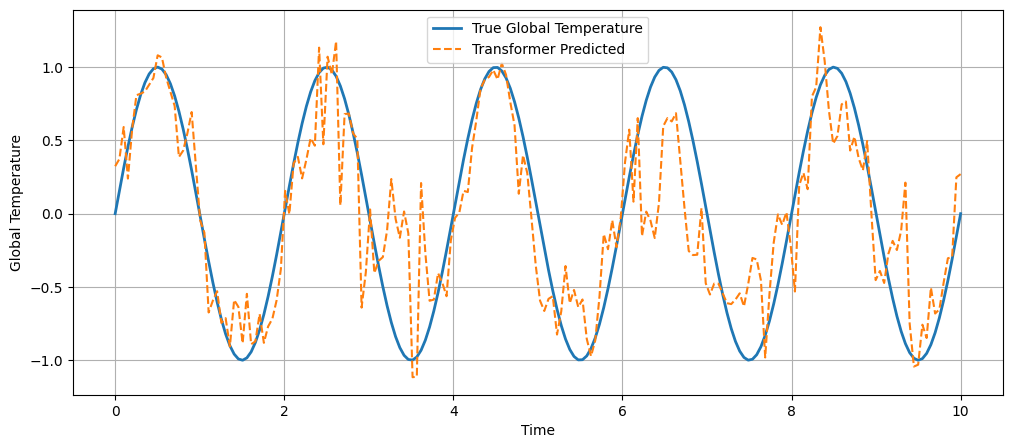

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(t, y[0, :, 0], label="True Global Temperature", linewidth=2)
plt.plot(t, y_pred[0, :, 0], label="Transformer Predicted", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Global Temperature")
plt.legend()
plt.grid(True)
plt.show()